# Heart Disease — Exploratory Data Analysis

Loads the cleaned dataset produced by `src/download_data.py`, plots distributions, correlations and class balance, and saves figures to `reports/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

df = pd.read_csv(ROOT / 'data' / 'heart_disease_clean.csv')
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


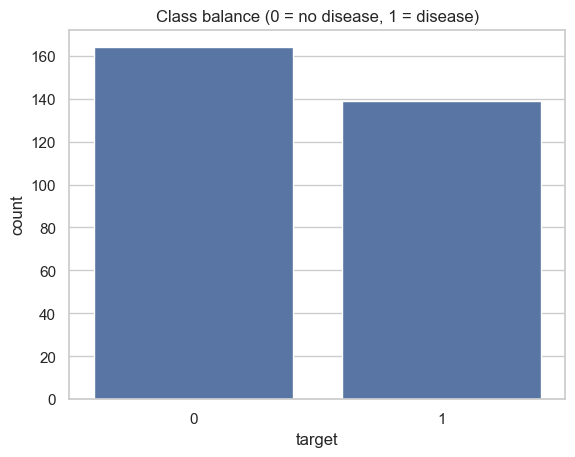

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [3]:
ax = sns.countplot(data=df, x='target')
ax.set_title('Class balance (0 = no disease, 1 = disease)')
plt.savefig(REPORTS / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['target'].value_counts(normalize=True))

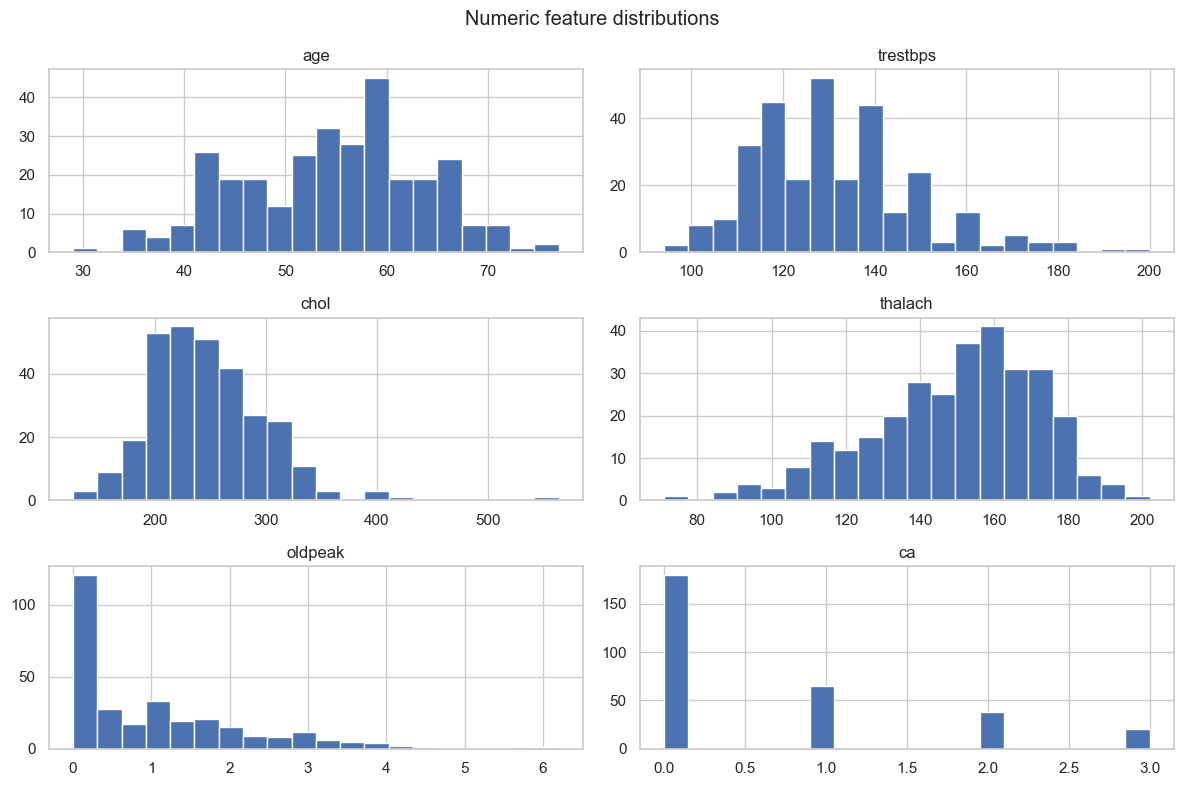

In [4]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Numeric feature distributions')
plt.tight_layout()
plt.savefig(REPORTS / 'hist_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

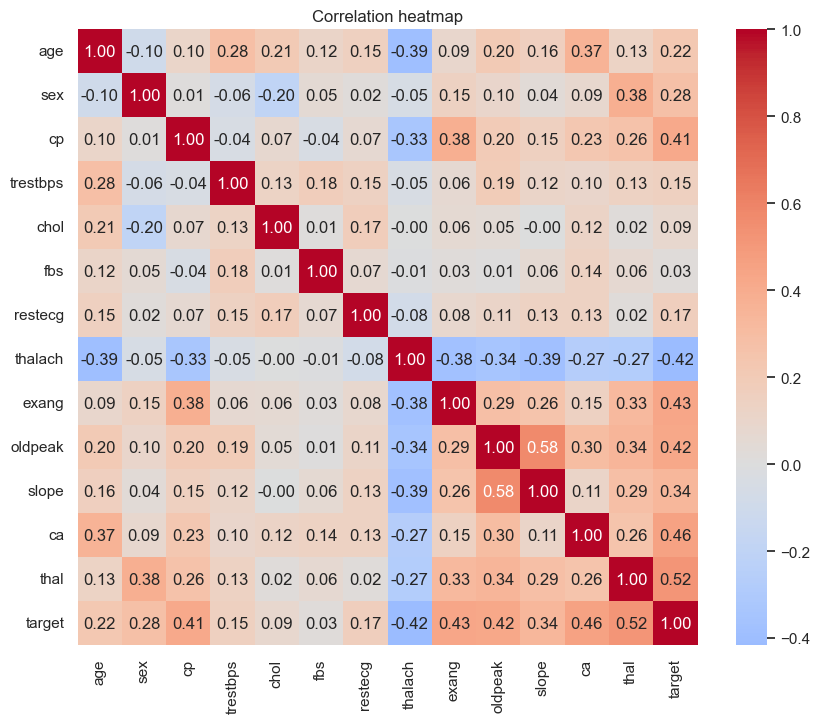

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.savefig(REPORTS / 'corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

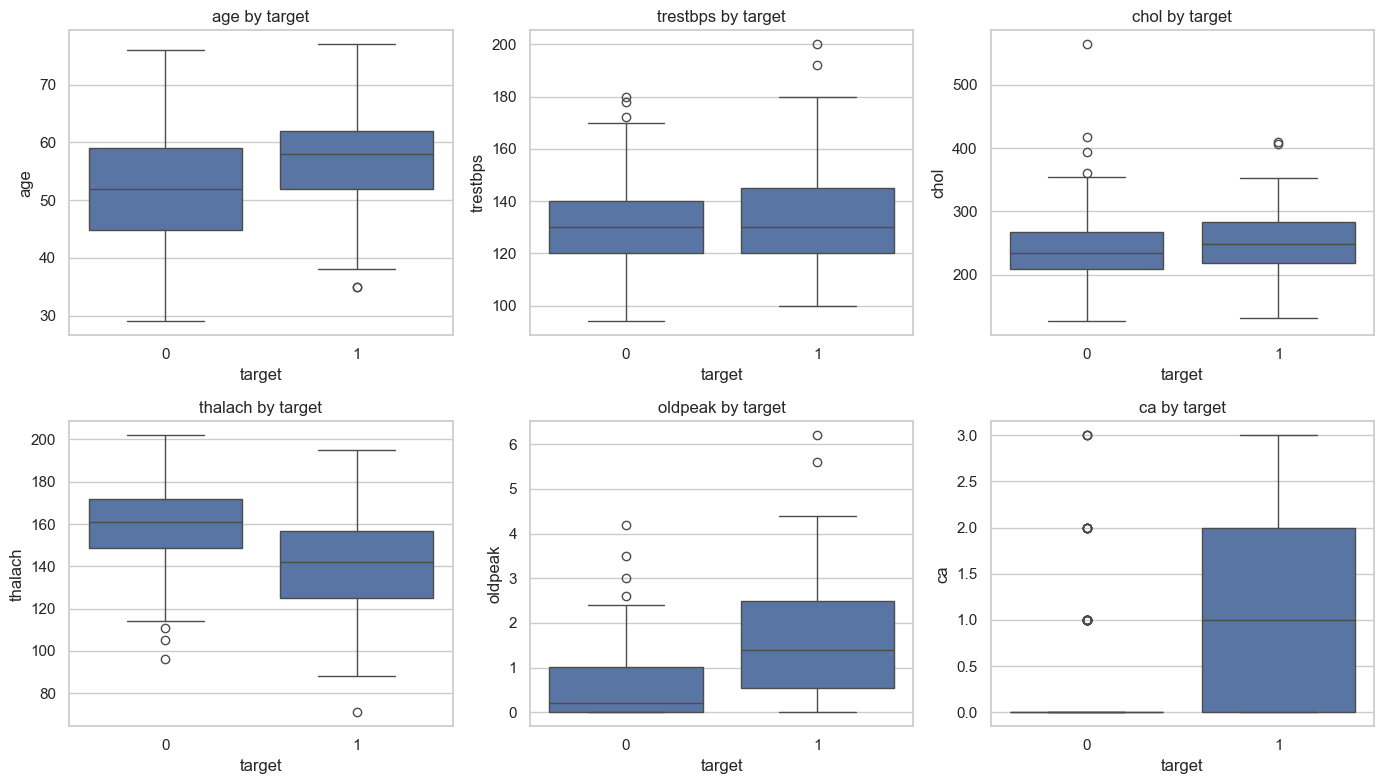

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='target', y=col, ax=ax)
    ax.set_title(f'{col} by target')
plt.tight_layout()
plt.savefig(REPORTS / 'box_by_target.png', dpi=150, bbox_inches='tight')
plt.show()